# Need to install decryption Libraries

In [133]:
%pip install msoffcrypto-tool openpyxl 

Note: you may need to restart the kernel to use updated packages.


# Install libraries

In [134]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import msoffcrypto
import io
import openpyxl
import statsmodels.api as sm
from scipy.optimize import curve_fit
from dotenv import load_dotenv

from pathlib import Path

# Get the password from env

In [135]:
load_dotenv()
password = os.getenv("PAROS_PASSWORD")

if not password:
    print("ERROR: Password not found in the env")
else:
    print("SUCCESS: Password found in the env")

SUCCESS: Password found in the env


# Setting up file paths

In [136]:
CURRENT_DIRECTORY = Path(os.getcwd()).resolve()

# Find project root by walking up until the "datasets" folder is found
PROJECT_ROOT = next(
    p for p in [CURRENT_DIRECTORY, *CURRENT_DIRECTORY.parents]
    if (p / "datasets").exists()
)

# Set the base dataset path
BASE_DATASET_PATH = PROJECT_ROOT / "datasets"

# Define file paths directly inside the datasets folder
ENCRYPTED_FILE_PATH = BASE_DATASET_PATH / "DataExportParos_SG_Apr10-Dec21_with postal codes_27Mar25_encryptedv1.xlsx"
CLEANED_DATASET_PATH = BASE_DATASET_PATH / "PAROS_Dataset_Cleaned.csv"

print("CURRENT_DIRECTORY:", CURRENT_DIRECTORY)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("ENCRYPTED_FILE_PATH exists:", ENCRYPTED_FILE_PATH.exists())
display(ENCRYPTED_FILE_PATH)

CURRENT_DIRECTORY: /home/axlee/Desktop/SINGHEALTH/WORK/AED-OHCA/src/Cleaning PAROS dataset
PROJECT_ROOT: /home/axlee/Desktop/SINGHEALTH/WORK/AED-OHCA
ENCRYPTED_FILE_PATH exists: True


PosixPath('/home/axlee/Desktop/SINGHEALTH/WORK/AED-OHCA/datasets/DataExportParos_SG_Apr10-Dec21_with postal codes_27Mar25_encryptedv1.xlsx')

# Decrypting the file

In [137]:
decrypted_workbook = io.BytesIO()
print(f"Attempting to decrypt: {ENCRYPTED_FILE_PATH.name}...")

try:
    with open(ENCRYPTED_FILE_PATH, 'rb') as file:
        office_file = msoffcrypto.OfficeFile(file)
        office_file.load_key(password=password)
        office_file.decrypt(decrypted_workbook)

    # Load the decrypted memory object directly into a Pandas DataFrame
    df = pd.read_excel(decrypted_workbook)
    print("✅ RAW PAROS dataset successfully decrypted and loaded!")
    
    # Show the first 3 rows to confirm
    # display(df.head(3))

except FileNotFoundError:
    print(f"❌ Error: Could not find the file at {ENCRYPTED_FILE_PATH}. Please check the path and filename.")
except openpyxl.utils.exceptions.InvalidFileException:
    print("❌ Error: Invalid password or unsupported Excel format.")
except Exception as e:
    print(f"❌ An error occurred: {e}")

Attempting to decrypt: DataExportParos_SG_Apr10-Dec21_with postal codes_27Mar25_encryptedv1.xlsx...


/home/axlee/miniconda3/envs/geospatial_env/lib/python3.14/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


✅ RAW PAROS dataset successfully decrypted and loaded!


In [138]:
print(df.columns.tolist())


['Case #', 'Country', 'City', 'Site #', 'Patient brought in by', 'Date of Incident', 'Location of incident', 'Location Unknown', 'Location Type', 'Location Type Other', 'Age', 'Age Modifier', 'Gender', 'Race', 'Medical History - No', 'Medical History - Unknown', 'Medical History - Heart disease', 'Medical History - Diabetes', 'Medical History - Cancer', 'Medical History - Hypertension', 'Medical History - Renal Disease', 'Medical History - Respiratory Disease', 'Medical History - Hyperlipidemia', 'Medical History - Stroke', 'Medical History - HIV', 'Medical History - Other', 'Time call received at dispatch center', 'No First Responder dispatched', 'Time First Responder dispatched', 'Time Ambulance dispatched', 'Time First Responder arrived at scene', 'Time Ambulance arrived at scene', 'Time EMS arrived at patient side', 'Time Ambulance left scene', 'Time Ambulance arrived at ED', 'Estimated time of arrest', 'Estimated time of arrest unknown', 'Arrest witnessed by', 'Bystander CPR', 'DA

# Fill missing values with NaN

In [139]:
# strip whitespace from all string cells first
df = df.apply(lambda col: col.map(lambda x: x.strip() if isinstance(x, str) else x))

missing_tokens = [
    "", " ", "  ", "N/A", "n/a", "NA", "na", "NULL", "null", "None", "none", "-"
]
df = df.replace(missing_tokens, np.nan)

# missing_summary = (
#     df.isna().mean()
#       .mul(100)
#       .sort_values(ascending=False)
#       .rename("missing_pct")
#       .to_frame()
# )
# display(missing_summary.head(30))
display(df.head(3))

/tmp/ipykernel_14443/3761420766.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(missing_tokens, np.nan)


,Case #,Country,City,Site #,Patient brought in by,Date of Incident,Location of incident,Location Unknown,Location Type,Location Type Other,...,EQ-5D Unknown,EQ-5D Mobility,EQ-5D Self-care,EQ-5D Usual activities,EQ-5D Pain/Discomfort,EQ-5D Anxiety/Depression,EQ-5D VAS,General Comments,Date Created,Date Last Saved
0,SGSIN0213,SG,SIN,2,EMS,2010-04-01,470146.0,NaN,Home Residence,HDB Level 7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,2011-02-22
1,SGSIN0218,SG,SIN,2,EMS,2010-04-01,520926.0,NaN,Home Residence,HDB Level 2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,2011-02-22
2,SGSIN6480,SG,SIN,6,EMS,2010-04-01,560565.0,NaN,Healthcare Facility,NKF Dialysis Centre,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,2012-04-18


# Cleaning Columns and standardizing spelling

### Country

In [140]:
display(df['Country'].unique())

array(['SG', nan], dtype=object)

### City

In [141]:
display(df['City'].unique())

array(['SIN', nan], dtype=object)

### Site #

In [142]:
display(df['Site #'].unique())

array([ 2,  6,  5,  7,  1,  3,  4,  8,  9, 10])

### Patient brought in by

In [143]:
# Before
display(df['Patient brought in by'].unique())

df['Patient brought in by'] = (
    df['Patient brought in by']
    .astype(str)
    .str.strip()
    .str.title()
    .replace({
        'Nan': np.nan,
        'nan': np.nan
        })
)

# After
display(df['Patient brought in by'].unique())

array(['EMS', 'Private Ambulance', 'Own/Private Transport',
       'Public Transport', 'Own/Public Transport', 'Private ambulance',
       'Own/Private transport', 'Public transport',
       'Own/private transport'], dtype=object)

/tmp/ipykernel_14443/3760337211.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['Patient brought in by'] = (


array(['Ems', 'Private Ambulance', 'Own/Private Transport',
       'Public Transport', 'Own/Public Transport'], dtype=object)

### Date of Incident

In [144]:
display(df['Date of Incident'].unique())


<DatetimeArray>
['2010-04-01 00:00:00', '2010-04-02 00:00:00', '2010-04-03 00:00:00',
 '2010-04-06 00:00:00', '2010-04-07 00:00:00', '2010-04-08 00:00:00',
 '2010-04-09 00:00:00', '2010-04-10 00:00:00', '2010-04-12 00:00:00',
 '2010-04-13 00:00:00',
 ...
 '2021-12-30 00:04:26', '2021-12-30 02:44:44', '2021-12-30 09:13:50',
 '2021-12-30 11:30:48', '2021-12-30 15:09:26', '2021-12-30 15:44:57',
 '2021-12-30 16:59:12', '2021-12-30 18:12:38', '2021-12-30 19:31:39',
 '2021-12-31 00:00:00']
Length: 7468, dtype: datetime64[ns]

### Location of incident

In [145]:
display(df['Location of incident'].unique())


array([470146., 520926., 560565., ..., 462208., 462154., 530694.])

### Location Unknown

In [146]:
display(df['Location Unknown'].unique())

array([nan, 'Yes'], dtype=object)

### Location Type

In [147]:
display(df['Location Type'].unique())

df['Location Type'] = (
    df['Location Type']
    .astype(str)
    .str.strip()
    .str.title()
    .replace({
        'Others': 'Other',
        'Nan': np.nan,
        'nan': np.nan
    })
)

display(df['Location Type'].unique())

array(['Home Residence', 'Healthcare Facility', 'Place of Recreation',
       'Public/Commercial Building', 'Street/Highway', 'Other',
       'Industrial Place', 'In EMS/Private ambulance', 'Transport center',
       'Nursing Home', 'In EMS/private ambulance', 'Others',
       'Home residence', 'Nursing home', 'Public/Commercial building',
       'Place of recreation', 'Healthcare facility', 'Industrial place',
       'Street/highway'], dtype=object)

/tmp/ipykernel_14443/3605302868.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['Location Type'] = (


array(['Home Residence', 'Healthcare Facility', 'Place Of Recreation',
       'Public/Commercial Building', 'Street/Highway', 'Other',
       'Industrial Place', 'In Ems/Private Ambulance', 'Transport Center',
       'Nursing Home'], dtype=object)

### Location Type Other

In [148]:
display(df['Location Type Other'].unique())


df['Location Type Other'] = (
    df['Location Type Other']
    .astype(str)
    .str.strip()
    .str.title()
    .replace({
        'Hdb': 'HDB',
        'Nkf': 'NKF',
        'Nan': np.nan,
        'nan': np.nan
        })
)

display(df['Location Type Other'].unique())

array(['HDB Level 7', 'HDB Level 2', 'NKF Dialysis Centre', ...,
       'Hotel Royal', 'Shipyard Medical Clinic',
       'Construction site. Level 1'], dtype=object)

/tmp/ipykernel_14443/143645104.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['Location Type Other'] = (


array(['Hdb Level 7', 'Hdb Level 2', 'Nkf Dialysis Centre', ...,
       'Hotel Royal', 'Shipyard Medical Clinic',
       'Construction Site. Level 1'], dtype=object)

### Age

In [149]:
display(df['Age'].unique())

array([ 60,  64,  48,  50,  80,  70,  69,  71,  72,  43,  74,  62,  86,
        49,  46,  58,  56,  67,  68,  78,  73,   6,  63,  52,  44,  77,
        90,   0,  51,  41,  57,  32,  31,  76,  25,  42,  55,  97,  47,
        45,  66,  61,  29,  54,  82,  35,  83,  65,  75,  40,  81,  53,
        84,  30,  22,  89,  79,  88,  34,  85,  39,  23,  59,  92,  13,
        94,  37,  91,  36,  87,  33,   1,  28,  95,  26,  21,  98,  93,
         8,  38,   2,  96,  16,  20,  19, 110,   9,  12,  24,  14,  27,
       102,  17, 100,  10,  18,   3,   4,  15, 112,  99,  11,   5, 103,
       108, 114, 101, 107,   7, 115, 111, 105, 104, 121])

### Age Modifier

In [150]:
display(df['Age Modifier'].unique())

array(['Years', 'Months', 'Days'], dtype=object)

### Gender

In [151]:
display(df['Gender'].unique())

array(['Male', 'Female'], dtype=object)

### Race

In [152]:
display(df['Race'].unique())

df['Race'] = (
    df['Race']
    .astype(str)
    .str.strip()
    .str.title()
    .replace({
        'Others': 'Other',
        'other': 'Other',
        'Nan': np.nan,
        'nan': np.nan
    })
)

display(df['Race'].unique())

array(['Chinese', 'Malay', 'Indian', 'Other', 'Eurasian', 'Others',
       'other'], dtype=object)

/tmp/ipykernel_14443/273336778.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['Race'] = (


array(['Chinese', 'Malay', 'Indian', 'Other', 'Eurasian'], dtype=object)

### Medical History - No

In [153]:
display(df['Medical History - No'].unique())

df['Medical History - No'] = (
    df['Medical History - No']
    .replace({
        'yes': 'Yes',
        'Nan': np.nan,
        'nan': np.nan
    })
)

display(df['Medical History - No'].unique())

array([nan, 'Yes', 'No', 'yes'], dtype=object)

/tmp/ipykernel_14443/2531796311.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['Medical History - No'] = (


array([nan, 'Yes', 'No'], dtype=object)

### Medical History - Unknown

In [154]:
display(df['Medical History - Unknown'].unique())

array([nan, 'No', 'Yes'], dtype=object)

### Medical History - Heart disease

In [155]:
display(df['Medical History - Heart disease'].unique())

df['Medical History - Heart disease'] = (
    df['Medical History - Heart disease']
    .replace({
        'yes': 'Yes',
        'Nan': np.nan,
        'nan': np.nan
    })
)

display(df['Medical History - Heart disease'].unique())

array(['No', 'Yes', nan, 'yes'], dtype=object)

/tmp/ipykernel_14443/1901253222.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['Medical History - Heart disease'] = (


array(['No', 'Yes', nan], dtype=object)

### Medical History - Diabetes

In [156]:
display(df['Medical History - Diabetes'].unique())

df['Medical History - Diabetes'] = (
    df['Medical History - Diabetes']
    .replace({
        'YEs': 'Yes',
        'Nan': np.nan,
        'nan': np.nan
    })
)

display(df['Medical History - Diabetes'].unique())

array(['No', 'Yes', nan, 'YEs'], dtype=object)

/tmp/ipykernel_14443/2482940714.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['Medical History - Diabetes'] = (


array(['No', 'Yes', nan], dtype=object)

### Medical History - Cancer

In [157]:
display(df['Medical History - Cancer'].unique())


array(['No', nan, 'Yes'], dtype=object)

### Medical History - Hypertension

In [158]:
display(df['Medical History - Hypertension'].unique())


array(['No', 'Yes', nan], dtype=object)

### Medical History -  Renal Disease

In [159]:
display(df['Medical History - Renal Disease'].unique())

array(['No', 'Yes', nan], dtype=object)

### Medical History - Respiratory Disease

In [160]:
display(df['Medical History - Respiratory Disease'].unique())

array(['Yes', 'No', nan], dtype=object)

### Medical History - Hyperlipidemia

In [161]:
display(df['Medical History - Hyperlipidemia'].unique())

array(['No', nan, 'Yes'], dtype=object)

### Medical History - Stroke

In [162]:
display(df['Medical History - Stroke'].unique())

array(['No', nan, 'Yes'], dtype=object)

### Medical History - HIV

In [163]:
display(df['Medical History - HIV'].unique())

array(['No', nan, 'Yes'], dtype=object)

### Medical History - Other

In [164]:
display(df['Medical History - Other'].unique())

df['Medical History - Other'] = (
    df['Medical History - Other']
    .replace({
        'yes': 'Yes',
        'Nan': np.nan,
        'nan': np.nan
    })
)

display(df['Medical History - Other'].unique())

array(['No', nan, 'Yes', 'yes'], dtype=object)

/tmp/ipykernel_14443/1864607230.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['Medical History - Other'] = (


array(['No', nan, 'Yes'], dtype=object)

### Time call received at dispatch center

In [165]:
display(df['Time call received at dispatch center'].isna().sum())

np.int64(295)

### No First Responder dispatched

In [166]:
display(df['No First Responder dispatched'].unique())

array(['Yes', nan, 'No'], dtype=object)

### Time First Responder dispatched

In [167]:
display(df['Time First Responder dispatched'].isna().sum())

np.int64(18205)

### Time Ambulance dispatched

In [168]:
display(df['Time Ambulance dispatched'].isna().sum())

np.int64(295)

### Time First Responder arrived at scene

In [169]:
display(df['Time First Responder arrived at scene'].isna().sum())

np.int64(18382)

### Time Ambulance arrived at scene

In [170]:
display(df['Time Ambulance arrived at scene'].isna().sum())

np.int64(295)

### Time EMS arrived at patient side

In [171]:
display(df['Time EMS arrived at patient side'].isna().sum())

np.int64(296)

### Time Ambulance arrived at ED

In [172]:
display(df['Time Ambulance arrived at ED'].isna().sum())

np.int64(1485)

### Estimated time of arrest

In [173]:
display(df['Estimated time of arrest'].isna().sum())

np.int64(186)

### Estimated time of arrest unknown

In [174]:
display(df['Estimated time of arrest unknown'].unique())

array([nan, 'Yes'], dtype=object)

### Arrest witnessed by

In [175]:
display(df['Arrest witnessed by'].unique())

df['Arrest witnessed by'] = (
    df['Arrest witnessed by']
    .astype(str)
    .str.strip()
    .str.title()
    .replace({
        'Ambulance Crew': 'Ems/Private Ambulance',
        'Nan': np.nan,
        'nan': np.nan
    })
)

display(df['Arrest witnessed by'].unique())

array(['Not witnessed', 'Bystander - Family', 'EMS/Private ambulance',
       'Bystander - Lay Person', 'Bystander - Healthcare provider',
       'Bystander - Lay person', 'not witnessed',
       'Bystander - healthcare provider', 'Bystander - family',
       'Bystander - lay Person', 'Bystander - lay person',
       'Ambulance crew', 'bystander - lay Person'], dtype=object)

/tmp/ipykernel_14443/2848146372.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['Arrest witnessed by'] = (


array(['Not Witnessed', 'Bystander - Family', 'Ems/Private Ambulance',
       'Bystander - Lay Person', 'Bystander - Healthcare Provider'],
      dtype=object)

### Bystander CPR 

In [176]:
display(df['Bystander CPR'].unique())

array(['Yes', 'No'], dtype=object)

### DA-CPR

In [177]:
display(df['DA-CPR'].unique())

array([nan, 'No', 'Yes'], dtype=object)

### First CPR initiated by

In [178]:
display(df['First CPR initiated by'].unique())

df['First CPR initiated by'] = (
    df['First CPR initiated by']
    .astype(str)
    .str.strip()
    .str.title()
    .replace({
        'Nan': np.nan,
        'nan': np.nan
    })

)

display(df['First CPR initiated by'].unique())

array(['Bystander - Family', 'Ambulance Crew',
       'Bystander - Healthcare provider', 'Bystander - Lay Person',
       'No CPR Initiated', 'First Responder', 'No CPR initiated',
       'Ambulance crew', 'First responder', 'Bystander - Lay person',
       'Bystander - Healthcare Provider'], dtype=object)

/tmp/ipykernel_14443/3429403011.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['First CPR initiated by'] = (


array(['Bystander - Family', 'Ambulance Crew',
       'Bystander - Healthcare Provider', 'Bystander - Lay Person',
       'No Cpr Initiated', 'First Responder'], dtype=object)

### Bystander AED applied

In [179]:
display(df['Bystander AED applied'].unique())

array(['No', 'Yes', nan], dtype=object)

### Resuscitation attempted by EMS/Private ambulance

In [180]:
display(df['Resuscitation attempted by EMS/Private ambulance'].unique())

array(['Yes', nan, 'No'], dtype=object)

### First arrest rhythm

In [181]:
display(df['First arrest rhythm'].unique())

df['First arrest rhythm'] = (
    df['First arrest rhythm']
    .astype(str)
    .str.strip()
    .str.title()
    .replace({
        'Nan': np.nan,
    })
)

display(df['First arrest rhythm'].unique())

array(['PEA', 'Unknown Unshockable Rhythm', 'VF', 'Asystole', nan,
       'Unknown', 'Unknown Shockable Rhythm', 'VT',
       'Unknown unshockable rhythm', 'Unknown shockable rhythm',
       'asystole'], dtype=object)

/tmp/ipykernel_14443/167924426.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['First arrest rhythm'] = (


array(['Pea', 'Unknown Unshockable Rhythm', 'Vf', 'Asystole', nan,
       'Unknown', 'Unknown Shockable Rhythm', 'Vt'], dtype=object)

### Time CPR started by EMS/Private ambulance

In [182]:
display(df['Time CPR started by EMS/Private ambulance'].isna().sum())

np.int64(683)

### Time CPR started Unknown

In [183]:
display(df['Time CPR started Unknown'].unique())

array([nan, 'Yes'], dtype=object)

### Time AED applied by EMS/Private ambulance

In [184]:
display(df['Time AED applied by EMS/Private ambulance'].isna().sum())

np.int64(1176)

### Time AED applied Unknown

In [185]:
display(df['Time AED applied Unknown'].unique())

array([nan, 'Yes'], dtype=object)

### Prehospital Defibrillation

In [186]:
display(df['Prehospital Defibrillation'].unique())

array(['Yes', 'No', nan], dtype=object)

### Time of first shock given

In [187]:
display(df['Time of first shock given'].isna().sum())

np.int64(23079)

### Time of first shock Unknown

In [188]:
display(df['Time of first shock Unknown'].unique())

array([nan, 'Yes'], dtype=object)

### Defibrillation performed by - First Responder

In [189]:
display(df['Defibrillation performed by - First Responder'].unique())

array([nan, 'Yes'], dtype=object)

### Defibrillation performed by - Ambulance Crew

In [190]:
display(df['Defibrillation performed by - Ambulance Crew'].unique())

array(['Yes', nan], dtype=object)

### Defibrillation performed by - Bystander - Healthcare provider

In [191]:
display(df['Defibrillation performed by - Bystander - Healthcare provider'].unique())

array([nan, 'Yes'], dtype=object)

### Defibrillation performed by - Bystander - Lay Person

In [192]:
display(df['Defibrillation performed by - Bystander - Lay Person'].unique())

array([nan, 'Yes'], dtype=object)

### Defibrillation performed by - Bystander - Family

In [193]:
display(df['Defibrillation performed by - Bystander - Family'].unique())

array([nan, 'Yes'], dtype=object)

### Mechanical CPR device used by EMS/Private ambulance

In [194]:
display(df['Mechanical CPR device used by EMS/Private ambulance'].unique())

array(['No', nan, 'Yes'], dtype=object)

### If 'Yes', please specify

In [195]:
display(df["If 'Yes', please specify"].unique())

array([nan, 'Active Compression Decompression', 'Load-Distributing Band',
       'Mechanical Piston'], dtype=object)

### Prehospital advanced airway

In [196]:
display(df["Prehospital advanced airway"].unique())

array(['Yes', 'No', nan], dtype=object)

### If 'Yes', please specify
- This is another column with the same numbner, pandas will label it as .1

In [197]:
display(df["If 'Yes', please specify.1"].unique())

array(['LMA', 'Oral/Nasal ET', nan, 'Other', 'King airway', 'Combitube'],
      dtype=object)

### Prehospital drug administration

In [198]:
display(df["Prehospital drug administration"].unique())

array(['No', 'Yes', nan], dtype=object)

### Epinephrine

In [199]:
display(df["Epinephrine"].unique())

array([nan, 'Yes'], dtype=object)

### Atropine

In [200]:
display(df["Atropine"].unique())

array([nan, 'Yes'], dtype=object)

### Amiodarone

In [201]:
display(df["Amiodarone"].unique())

array([nan, 'Yes'], dtype=object)

### Bicarbonate

In [202]:
display(df["Bicarbonate"].unique())

array([nan, 'Yes'], dtype=object)

### Lidocaine

In [203]:
display(df["Lidocaine"].unique())

array([nan, 'Yes'], dtype=object)

### Dextrose

In [204]:
display(df["Dextrose"].unique())

array([nan, 'Yes'], dtype=object)

### Other

In [205]:
display(df["Other"].unique())

array([nan, 'Yes'], dtype=object)

### Return of spontaneous circulation at scene/en-route

In [206]:
display(df["Return of spontaneous circulation at scene/en-route"].unique())

array(['No', 'Yes', nan], dtype=object)

### If 'Yes', specify time

In [207]:
display(df["If 'Yes', specify time"].isna().sum())

np.int64(26103)

### Final status at scene

In [208]:
display(df["Final status at scene"].unique())

array(['Conveyed to ED', nan, 'Pronounced dead at scene'], dtype=object)

### Cause of arrest

In [209]:
display(df["Cause of arrest"].unique())

array([nan, 'Non-Trauma'], dtype=object)

### If 'Non-Trauma', please specify

In [210]:
display(df["If 'Non-Trauma', please specify"].unique())

array([nan, 'Presumed Cardiac Etiology', 'Other', 'Respiratory'],
      dtype=object)

### Level of destination hospital

In [211]:
display(df["Level of destination hospital"].unique())

array(['Tertiary', nan], dtype=object)

### Destination Hospital

In [212]:
display(df["Destination Hospital"].unique())

array(['CGH', 'TTSH', 'NUH', 'SGH', nan, 'NTFGH', 'KKH', 'KTPH', 'SKGH',
       'RAFFLES HOSPITAL'], dtype=object)

### Patient's status at ED arrival

In [213]:
display(df["Patient's status at ED arrival"].unique())

array(['Ongoing resuscitation', 'ROSC', nan,
       'Transported without resuscitation'], dtype=object)

### Date of arrival at ED

In [214]:
display(df["Date of arrival at ED"].isna().sum())

np.int64(948)

### Time of arrival at ED

In [215]:
display(df["Time of arrival at ED"].isna().sum())

np.int64(1191)

### Patient status on arrival at ED - Pulse

In [216]:
display(df["Patient status on arrival at ED - Pulse"].unique())

array(['No', 'Yes', nan], dtype=object)

### Patient status on arrival at ED - Breathing

In [217]:
display(df["Patient status on arrival at ED - Breathing"].unique())


array(['No', 'Yes', nan], dtype=object)

### Cardiac rhythm on arrival at ED

In [218]:
display(df['Cardiac rhythm on arrival at ED'].unique())

array(['Asystole', 'PEA', 'Sinus or other perfusing rhythm', 'VT', 'VF',
       nan], dtype=object)

### 

### ED Defibrillation performed

In [219]:
display(df["ED Defibrillation performed"].unique())

array(['No', 'Yes', nan], dtype=object)

### Mechanical CPR device used at ED

In [220]:
display(df["Mechanical CPR device used at ED"].unique())

array(['No', 'Yes', nan], dtype=object)

### If 'Yes', please specify

In [221]:
display(df["If 'Yes', please specify.3"].unique())

array([nan, 'Load-Distributing Band', 'Active Compression Decompression',
       'Other', 'Mechanical Piston'], dtype=object)

### Advanced airway used at ED

In [222]:
display(df["Advanced airway used at ED"].unique())

df["Advanced airway used at ED"] = (
    df["Advanced airway used at ED"]
    .replace({
        'yES': 'Yes',
        'Nan': np.nan,
        'nan': np.nan
    })
)

display(df["Advanced airway used at ED"].unique())

array(['Yes', 'No', nan, 'yES'], dtype=object)

/tmp/ipykernel_14443/2241593448.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df["Advanced airway used at ED"] = (


array(['Yes', 'No', nan], dtype=object)

### If 'Yes', please specify

In [223]:
display(df["If 'Yes', please specify.4"].unique())

array(['Oral/Nasal ET', nan, 'LMA', 'Other', 'King airway', 'Combitube'],
      dtype=object)

### Drug administered at ED

In [224]:
display(df["Drug administered at ED"].unique())

array(['Yes', 'No', nan], dtype=object)

### Epinephrine

In [225]:
display(df["Epinephrine.1"].unique())

array(['Yes', nan], dtype=object)

### Atropine

In [226]:
display(df["Atropine.1"].unique())

array(['Yes', nan], dtype=object)

### Bicarbonate

In [227]:
display(df["Bicarbonate.1"].unique())

array([nan, 'Yes'], dtype=object)

### Lidocaine

In [228]:
display(df["Lidocaine.1"].unique())

array([nan, 'Yes'], dtype=object)

### Dextrose

In [229]:
display(df["Dextrose.1"].unique())

array([nan, 'Yes'], dtype=object)

### Other

In [230]:
display(df["Other.1"].unique())

array([nan, 'Yes'], dtype=object)

### Return of spontaneous circulation at ED

In [231]:
display(df["Return of spontaneous circulation at ED"].unique())

df["Return of spontaneous circulation at ED"] = (
    df["Return of spontaneous circulation at ED"]
    .astype(str)
    .str.strip()
    .str.title()
    .replace({
        'Nan': np.nan,
        'nan': np.nan
    })
)

display(df["Return of spontaneous circulation at ED"].unique())

array(['Yes', 'No', 'Not Applicable', nan, 'Not applicable', 'yes', 'no'],
      dtype=object)

/tmp/ipykernel_14443/1074867267.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df["Return of spontaneous circulation at ED"] = (


array(['Yes', 'No', 'Not Applicable', nan], dtype=object)

### If 'Yes', specify time

In [232]:
display(df["If 'Yes', specify time.1"].isna().sum())


np.int64(22695)

### ED Rosc Time Unknown

In [233]:
display(df["ED Rosc Time Unknown"].unique())


array(['Yes', nan, datetime.time(20, 45), datetime.time(0, 35),
       datetime.time(4, 5), datetime.time(16, 41), datetime.time(8, 35)],
      dtype=object)

### Any ROSC

In [234]:
display(df["ANY ROSC"].unique())


array(['Yes', 'No', nan], dtype=object)

### Emergency PCI performed

In [235]:
display(df["Emergency PCI performed"].unique())

df["Emergency PCI performed"] = (
    df["Emergency PCI performed"]
    .astype(str)
    .str.strip()
    .str.title()
    .replace({
        'Nan': np.nan,
        'nan': np.nan
    })
)

display(df["Emergency PCI performed"].unique())

array(['No', 'Yes', nan, 'NO'], dtype=object)

/tmp/ipykernel_14443/2687189223.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df["Emergency PCI performed"] = (


array(['No', 'Yes', nan], dtype=object)

### Emergency CABG performed

In [236]:
display(df["Emergency CABG performed"].unique())

array(['No', 'Yes', nan], dtype=object)

### Hypothermia therapy initiated

In [237]:
display(df["Hypothermia therapy initiated"].unique())

df["Hypothermia therapy initiated"] = (
    df["Hypothermia therapy initiated"]
    .astype(str)
    .str.strip()
    .str.title()
    .replace({
        'Nan': np.nan,
        'nan': np.nan
    })
)

display(df["Hypothermia therapy initiated"].unique())

array(['No', 'Yes', nan, 'no'], dtype=object)

/tmp/ipykernel_14443/799960473.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df["Hypothermia therapy initiated"] = (


array(['No', 'Yes', nan], dtype=object)

### ECMO therapy initiated

In [238]:
display(df["ECMO therapy initiated"].unique())

df["ECMO therapy initiated"] = (
    df["ECMO therapy initiated"]
    .astype(str)
    .str.strip()
    .str.title()
    .replace({
        'Nan': np.nan,
        'nan': np.nan
    })
)
display(df["ECMO therapy initiated"].unique())

array(['No', 'Yes', nan, 'no'], dtype=object)

/tmp/ipykernel_14443/2267519392.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df["ECMO therapy initiated"] = (


array(['No', 'Yes', nan], dtype=object)

### Cause of arrest

In [239]:
display(df["Cause of arrest"].unique())


array([nan, 'Non-Trauma'], dtype=object)

### If 'Non-Trauma', please specify

In [240]:
display(df["If 'Non-Trauma', please specify"].unique())

array([nan, 'Presumed Cardiac Etiology', 'Other', 'Respiratory'],
      dtype=object)

### Reason for discontinuing CPR at ED

In [241]:
display(df["Reason for discontinuing CPR at ED"].unique())

array(['Death', 'ROSC', 'DNAR', 'ECMO therapy', nan], dtype=object)

### Outcome of patient

In [242]:
display(df["Outcome of patient"].unique())

df["Outcome of patient"] = (
    df["Outcome of patient"]
    .astype(str)
    .str.strip()
    .str.title()
    .replace({
        'Nan': np.nan,
        'nan': np.nan
    })
)

display(df["Outcome of patient"].unique())

array(['Died in ED', 'Admitted', 'Transferred to another hospital', nan,
       'Unknown', 'died in ED'], dtype=object)

/tmp/ipykernel_14443/4162672797.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df["Outcome of patient"] = (


array(['Died In Ed', 'Admitted', 'Transferred To Another Hospital', nan,
       'Unknown'], dtype=object)

### Patient Status

In [243]:
display(df["Patient status"].unique())

df["Patient status"] = (
    df["Patient status"]
    .astype(str)
    .str.strip()
    .str.title()
    .replace({
        'Nan': np.nan,
        'nan': np.nan
    })
)

display(df["Patient status"].unique())

array([nan, 'Died in the hospital', 'Discharged Alive',
       'Remains in hospital at 30th day post arrest', 'Discharged alive'],
      dtype=object)

/tmp/ipykernel_14443/2804994856.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df["Patient status"] = (


array([nan, 'Died In The Hospital', 'Discharged Alive',
       'Remains In Hospital At 30Th Day Post Arrest'], dtype=object)

### Date of Discharge or Death

In [244]:
display(df["Date of Discharge or Death"].isna().sum())

np.int64(23991)

### Patient neurological status - Cerebral

In [245]:
display(df["Patient neurological status - Cerebral"].unique())

array([nan,  2.,  4.,  1.,  3.])

### Patient neurological status - Overall

In [246]:
display(df["Patient neurological status - Overall"].unique())

array([nan,  2.,  4.,  1.,  3.])

### Patient neurological status - Unknown

In [247]:
display(df["Patient neurological status - Unknown"].unique())

array([nan, 'Yes'], dtype=object)

### EQ-5D Unknown

In [248]:
display(df["EQ-5D Unknown"].unique())

array([nan, 'Yes'], dtype=object)

### EQ-5D Mobility

In [249]:
display(df["EQ-5D Mobility"].unique())

array([nan, 'No problem', 'Some problems', 'Confined to bed'],
      dtype=object)

### EQ-5D Self-care

In [250]:
display(df["EQ-5D Self-care"].unique())

array([nan, 'No problem', 'Some problems', 'Unable to wash or dress'],
      dtype=object)

### EQ-5D Usual activities

In [251]:
display(df["EQ-5D Usual activities"].unique())

array([nan, 'No problem', 'Some problems', 'Unable to perform'],
      dtype=object)

### EQ-5D Pain/Discomfort

In [252]:
display(df["EQ-5D Pain/Discomfort"].unique())

array([nan, 'Moderate', 'No problem'], dtype=object)

### EQ-5D Anxiety/Depression

In [253]:
display(df["EQ-5D Anxiety/Depression"].unique())

array([nan, 'Moderate', 'Extreme'], dtype=object)

### EQ-5D VAS

In [254]:
display(df["EQ-5D VAS"].unique())

array([ nan,  80.,  70.,  75., 100.,  98.,  85.,  50.,  95.,  52.,  90.,
        60.,  65.,  40.,  30.])

### General Comments

In [255]:
display(df["General Comments"].unique())


array([nan,
       'Susan Yap (10/27/2010 18:43): EQ-5D was not done because consent form has not been approved by CIRB. Patient died on 16/06/2010.',
       'ePAROS Administrator (02/06/2013 15:01): VT with pulse, no shock given.',
       'Singyi Neo (10/19/2011 10:21): FRP arrived at scene later than paramedics',
       'ePAROS Administrator (02/06/2013 15:02): Unwitnessed arrest so unable to shock according to paramedic.',
       'Benjamin Liang (02/11/2011 10:15): Terminal discharge',
       'Singyi Neo (08/26/2011 16:14): Delay in CPR start time: need to extricate patient from vehicle at the roadside.',
       'ePAROS Administrator (09/15/2011 11:14): Hotel doctor administered adrenaline, insert ET and shocked patient.',
       "Singyi Neo (08/26/2011 17:54): NRIC: S7106884F - Keyed in wrong hospital code, hence generate this new form to subs. the previous form<br>Singyi Neo (08/26/2011 18:04): #13 & #14 : Delay in EMS arrival as there was difficulties accessing patient's side",
 

### Date Created

In [256]:
display(df["Date Created"].unique())

<DatetimeArray>
[                'NaT', '2017-11-01 00:00:00', '2018-01-18 00:00:00',
 '2017-11-02 00:00:00', '2017-11-10 00:00:00', '2017-11-27 00:00:00',
 '2017-11-15 00:00:00', '2017-10-12 00:00:00', '2017-10-17 00:00:00',
 '2017-11-28 00:00:00',
 ...
 '2018-07-03 00:00:00', '2018-07-02 00:00:00', '2018-11-28 00:00:00',
 '2018-11-30 00:00:00', '2018-12-04 00:00:00', '2019-01-03 00:00:00',
 '2018-12-28 00:00:00', '2019-01-02 00:00:00', '2019-01-04 00:00:00',
 '2019-01-25 00:00:00']
Length: 147, dtype: datetime64[ns]

### Date Last Saved

In [257]:
display(df["Date Last Saved"].unique())

<DatetimeArray>
['2011-02-22 00:00:00', '2012-04-18 00:00:00', '2012-04-13 00:00:00',
 '2013-05-31 00:00:00', '2011-02-16 00:00:00', '2012-11-08 00:00:00',
 '2010-11-23 00:00:00', '2011-02-23 00:00:00', '2013-02-07 00:00:00',
 '2017-03-01 00:00:00',
 ...
 '2018-11-28 00:00:00', '2018-11-30 00:00:00', '2018-12-03 00:00:00',
 '2018-12-04 00:00:00', '2019-01-03 00:00:00', '2018-12-28 00:00:00',
 '2019-01-02 00:00:00', '2019-01-04 00:00:00', '2019-01-07 00:00:00',
 '2019-01-25 00:00:00']
Length: 634, dtype: datetime64[ns]

In [258]:
display(df.columns)

Index(['Case #', 'Country', 'City', 'Site #', 'Patient brought in by',
       'Date of Incident', 'Location of incident', 'Location Unknown',
       'Location Type', 'Location Type Other',
       ...
       'EQ-5D Unknown', 'EQ-5D Mobility', 'EQ-5D Self-care',
       'EQ-5D Usual activities', 'EQ-5D Pain/Discomfort',
       'EQ-5D Anxiety/Depression', 'EQ-5D VAS', 'General Comments',
       'Date Created', 'Date Last Saved'],
      dtype='object', length=124)

# Drop columns that are not needed

In [259]:
exact_drops = [
    # Administrative & Identifiers
    'Case #', 'Country', 'City', 'Site #', 'Date Created', 'Date Last Saved', 'General Comments',
    
    # Advanced Paramedic Interventions
    'Prehospital advanced airway', 'Prehospital drug administration', 
    'Epinephrine', 'Atropine', 'Amiodarone', 'Bicarbonate', 'Lidocaine', 'Dextrose',
    'Mechanical CPR device used by EMS/Private ambulance', "If 'Yes', please specify",
    "If 'Yes', please specify.1", "If 'Yes', please specify.2",
    
    # Granular/Redundant Timestamps
    'Time Ambulance left scene', 'Estimated time of arrest', 'Estimated time of arrest unknown',
    
    # ED & In-Hospital Interventions
    'Advanced airway used at ED', 'Drug administered at ED', 
    'Emergency PCI performed', 'Emergency CABG performed', 
    'Hypothermia therapy initiated', 'ECMO therapy initiated',
    'Epinephrine.1', 'Atropine.1', 'Amiodarone.1', 'Bicarbonate.1', 'Lidocaine.1', 'Dextrose.1'
]

# 2. Group the remaining categories using list comprehensions
# This dynamically finds any column in your dataframe that contains these phrases
medical_history_cols = [col for col in df.columns if 'Medical History' in col]
cpr_started_cols = [col for col in df.columns if 'Time CPR started' in col]
aed_applied_cols = [col for col in df.columns if 'Time AED applied' in col]
eq5d_cols = [col for col in df.columns if 'EQ-5D' in col]

# 3. Combine everything into one master "Burn List"
master_drop_list = exact_drops + medical_history_cols + cpr_started_cols + aed_applied_cols + eq5d_cols

# 4. Drop them from the dataframe
df_clean = df.drop(columns=master_drop_list, errors='ignore')

print(f"Original columns: {len(df.columns)}")
print(f"Cleaned columns: {len(df_clean.columns)}")
print(f"Total columns dropped: {len(df.columns) - len(df_clean.columns)}")

Original columns: 124
Cleaned columns: 67
Total columns dropped: 57


# Exclusion Criteria

In [260]:
print("--- DATA TYPE PREPARATION & OUTCOME MAPPING ---")

# 1. Extract Year and Numeric Age
df_clean['Year'] = pd.to_datetime(df_clean['Date of Incident'], errors='coerce', format='mixed').dt.year
df_clean['Age'] = pd.to_numeric(df_clean['Age'], errors='coerce')

# 2. Parse Datetimes for the Primary Predictor (Time_to_Defib)
df_clean["Call_Time"] = pd.to_datetime(df_clean['Time call received at dispatch center'].astype(str), format="mixed", errors='coerce')
df_clean['Shock_Time'] = pd.to_datetime(df_clean['Time of first shock given'].astype(str), format='mixed', errors='coerce')

# Calculate time differences in minutes & fix midnight crossovers
df_clean['Time_to_Defib'] = (df_clean['Shock_Time'] - df_clean['Call_Time']).dt.total_seconds() / 60
df_clean.loc[df_clean['Time_to_Defib'] < 0, 'Time_to_Defib'] += 1440

# 3. CRITICAL FIX: Map all deaths to CPC 5 BEFORE dropping missing data
died_mask = (
    df_clean['Outcome of patient'].astype(str).str.contains('Died', case=False, na=False) |
    df_clean['Patient status'].astype(str).str.contains('Died', case=False, na=False) |
    df_clean['Final status at scene'].astype(str).str.contains('Died', case=False, na=False)
)
df_clean.loc[died_mask, 'Patient neurological status - Cerebral'] = '5'

/tmp/ipykernel_14443/3365402201.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_clean['Year'] = pd.to_datetime(df_clean['Date of Incident'], errors='coerce', format='mixed').dt.year
/tmp/ipykernel_14443/3365402201.py:5: FutureWarning:

--- DATA TYPE PREPARATION & OUTCOME MAPPING ---


/tmp/ipykernel_14443/3365402201.py:8: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_clean["Call_Time"] = pd.to_datetime(df_clean['Time call received at dispatch center'].astype(str), format="mixed", errors='coerce')
/tmp/ipykernel_14443/3

In [261]:
print("--- EXCLUSION CRITERIA ---")

# Start fresh from df_clean every time you run this cell to prevent Jupyter overwrite bugs
df_cohort = df_clean.copy()

n_start = len(df_cohort)
print(f"Total PAROS Registry: [N = {n_start}]")

# Restrict to 2014-2021 (Study Design)
df_cohort = df_cohort[df_cohort['Year'] >= 2014]
print(f"Post-2014 Baseline: [N = {len(df_cohort)}]")

# Exclude Age < 18
n_before = len(df_cohort)
df_cohort = df_cohort[df_cohort['Age'] >= 18]
print(f"Exclude Age < 18: Dropped {n_before - len(df_cohort)}")

# Exclude Non-Medical/Trauma
# NOTE: This currently drops 0 because the PAROS CSV provided by the team was pre-filtered 
# for medical etiologies. We are keeping this filter active defensively for future data pulls.
# n_before = len(df_cohort)
# keep_mask = df_cohort['Cause of arrest'].isna() | df_cohort['Cause of arrest'].astype(str).str.contains('Non-Trauma|Medical', case=False)
# df_cohort = df_cohort[keep_mask]
# print(f"Exclude Non-Medical/Trauma: Dropped {n_before - len(df_cohort)}")

# Exclude EMS Witnessed
n_before = len(df_cohort)
df_cohort = df_cohort[~df_cohort['Arrest witnessed by'].astype(str).str.contains('Ambulance|EMS', case=False, na=False)]
print(f"Exclude EMS Witnessed: Dropped {n_before - len(df_cohort)}")

# Exclude Non-Shockable
n_before = len(df_cohort)
df_cohort = df_cohort[df_cohort['First arrest rhythm'].astype(str).str.contains('VF|VT|Shockable', case=False, na=False)]
print(f"Exclude Non-Shockable: Dropped {n_before - len(df_cohort)}")

# Map all deaths to CPC 5 BEFORE dropping missing data
died_mask = (
    df_cohort['Outcome of patient'].astype(str).str.contains('Died', case=False, na=False) |
    df_cohort['Patient status'].astype(str).str.contains('Died', case=False, na=False) |
    df_cohort['Final status at scene'].astype(str).str.contains('Died', case=False, na=False)
)
df_cohort.loc[died_mask, 'Patient neurological status - Cerebral'] = '5'

# Exclude Fatal Missingness (Now it will only drop people who actually have missing CPC/Time)
n_before = len(df_cohort)
df_cohort = df_cohort.dropna(subset=['Patient neurological status - Cerebral', 'Time_to_Defib'])
print(f"Exclude Missing Timestamps/Outcomes: Dropped {n_before - len(df_cohort)}")

# Operational Boundary Filter (0-20 mins)
n_before = len(df_cohort)
df_cohort = df_cohort[(df_cohort['Time_to_Defib'] >= 0) & (df_cohort['Time_to_Defib'] <= 20)]
print(f"Exclude Time_to_Defib outside 0-20 mins: Dropped {n_before - len(df_cohort)}")

print(f"\nFINAL ANALYTIC COHORT: [N = {len(df_cohort)}]")

--- EXCLUSION CRITERIA ---
Total PAROS Registry: [N = 28665]
Post-2014 Baseline: [N = 23031]
Exclude Age < 18: Dropped 325
Exclude EMS Witnessed: Dropped 2070
Exclude Non-Shockable: Dropped 16647
Exclude Missing Timestamps/Outcomes: Dropped 1492
Exclude Time_to_Defib outside 0-20 mins: Dropped 421

FINAL ANALYTIC COHORT: [N = 2076]


# Building RECORD FLow Diagram

In [262]:
%pip install graphviz

Note: you may need to restart the kernel to use updated packages.


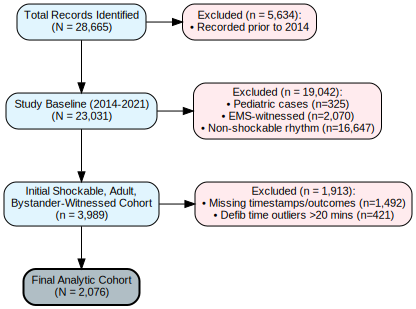

In [ ]:
import graphviz
from IPython.display import display

def generate_professional_record_flow():
    # --- 1. DATA DEFINITIONS ---
    total = 28665
    baseline = 23031
    
    # Tier 1: Clinical Pool (Age, EMS, Rhythm)
    # 23031 - 325 - 2070 - 16647 = 3989
    clinical_pool = 3989
    ex_clinical = 325 + 2070 + 16647
    
    # Tier 2: Analytic Pool (Missing Data, Outliers)
    # 3989 - 1492 - 421 = 2076
    final_n = 2076
    ex_data = 1492 + 421

    # --- 2. INITIALIZE DIAGRAM ---
    dot = graphviz.Digraph('Professional_Flow', comment='Participant Flow')
    dot.attr(rankdir='TB', nodesep='0.5', ranksep='0.6')
    
    # Global Styles
    dot.attr('node', shape='box', style='rounded,filled', fontname='Arial', fontsize='11')
    
    # --- 3. THE MAIN SPINE (Blue/Grey tones) ---
    dot.node('N0', f'Total Records Identified\n(N = {total:,})', fillcolor='#E1F5FE')
    dot.node('N1', f'Study Baseline (2014-2021)\n(N = {baseline:,})', fillcolor='#E1F5FE')
    dot.node('N2', f'Initial Shockable, Adult,\nBystander-Witnessed Cohort\n(n = {clinical_pool:,})', fillcolor='#E1F5FE')
    dot.node('N3', f'Final Analytic Cohort\n(N = {final_n:,})', fillcolor='#B0BEC5', penwidth='2')

    # --- 4. THE EXCLUSION TIERS (Grouped for Neatness) ---
    # Tier 1: Baseline filter
    dot.node('E1', f'Excluded (n = {total-baseline:,}):\n• Recorded prior to 2014', fillcolor='#FFEBEE')
    
    # Tier 2: Clinical filter (Grouped)
    clinical_text = (
        f"Excluded (n = {ex_clinical:,}):\n"
        f"• Pediatric cases (n=325)\n"
        f"• EMS-witnessed (n=2,070)\n"
        f"• Non-shockable rhythm (n=16,647)"
    )
    dot.node('E2', clinical_text, fillcolor='#FFEBEE', align='left')
    
    # Tier 3: Data Quality filter (Grouped)
    data_text = (
        f"Excluded (n = {ex_data:,}):\n"
        f"• Missing timestamps/outcomes (n=1,492)\n"
        f"• Defib time outliers >20 mins (n=421)"
    )
    dot.node('E3', data_text, fillcolor='#FFEBEE', align='left')

    # --- 5. DEFINE RELATIONSHIPS ---
    # Vertical Spine
    dot.edge('N0', 'N1')
    dot.edge('N1', 'N2')
    dot.edge('N2', 'N3')

    # Side Arrows (using 'ortho' style logic)
    dot.edge('N0', 'E1')
    dot.edge('N1', 'E2')
    dot.edge('N2', 'E3')

    # --- 6. ALIGNMENT ---
    for pair in [('N0', 'E1'), ('N1', 'E2'), ('N2', 'E3')]:
        with dot.subgraph() as s:
            s.attr(rank='same')
            s.node(pair[0]); s.node(pair[1])

    return dot

# Display in Jupyter
flow = generate_professional_record_flow()
display(flow)

# Save the diagram as a high-res PDF/PNG for your manuscript
# flow.render("STROBE_Participant_Flow", format="png", cleanup=True)

# Save FLOW Diagram

In [273]:
import os
from pathlib import Path
print("cwd:", os.getcwd())
print("output_dir (raw):", output_dir)
print("output_dir (abs):", Path(output_dir).resolve())
print("files in target:", list(Path(output_dir).resolve().glob("*")))

cwd: /home/axlee/Desktop/SINGHEALTH/WORK/AED-OHCA/src/Cleaning PAROS dataset
output_dir (raw): ../results/figures
output_dir (abs): /home/axlee/Desktop/SINGHEALTH/WORK/AED-OHCA/src/results/figures
files in target: [PosixPath('/home/axlee/Desktop/SINGHEALTH/WORK/AED-OHCA/src/results/figures/Figure_1_Participant_Flow.png')]


Success! Figure 1 saved to: ../Survival_Curve_Analysis/results/figures


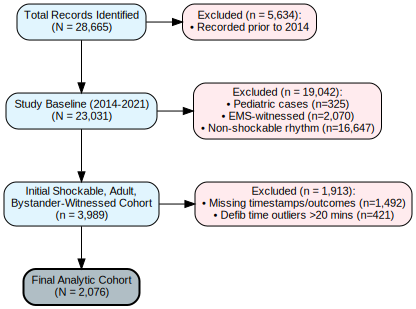

In [276]:
import os

# 1. Create the results folder if it doesn't exist
output_dir = "../Survival_Curve_Analysis/results/figures" # Adjusted for a standard 'notebooks' folder depth
os.makedirs(output_dir, exist_ok=True)

# 2. Render and save
flow = generate_professional_record_flow()

# This saves 'RECORD_Flow.png' into your results/figures folder
flow.render(filename=os.path.join(output_dir, "FLOW_Diagram_Exclusion_Criteria"), 
            format="png", 
            cleanup=True)

print(f"Success! Figure 1 saved to: {output_dir}")
display(flow)

# Save newly cleaned PAROS dataset

In [264]:
df_cohort.to_csv(CLEANED_DATASET_PATH, index=False)
df = pd.read_csv(CLEANED_DATASET_PATH)

display(df)

,Patient brought in by,Date of Incident,Location of incident,Location Unknown,Location Type,Location Type Other,Age,Age Modifier,Gender,Race,...,Outcome of patient,Patient status,Date of Discharge or Death,Patient neurological status - Cerebral,Patient neurological status - Overall,Patient neurological status - Unknown,Year,Call_Time,Shock_Time,Time_to_Defib
0,Ems,2014-01-01,238889.0,NaN,Transport Center,Dhoby Ghaut Mrt Level B1,59,Years,Male,Chinese,...,Died In Ed,NaN,NaN,5.0,NaN,NaN,2014,2026-04-05 22:28:12,2026-04-05 22:39:17,11.083333
1,Ems,2014-01-05,272018.0,NaN,Public/Commercial Building,Level 2,66,Years,Male,Chinese,...,Died In Ed,NaN,NaN,5.0,NaN,NaN,2014,2026-04-05 15:00:42,2026-04-05 15:16:49,16.116667
2,Ems,2014-01-07,760105.0,NaN,Street/Highway,Level 1,80,Years,Male,Indian,...,Admitted,Remains In Hospital At 30Th Day Post Arrest,NaN,4.0,4.0,NaN,2014,2026-04-05 12:05:46,2026-04-05 12:14:08,8.366667
3,Ems,2014-01-07,150166.0,NaN,Public/Commercial Building,Level 2,60,Years,Male,Malay,...,Died In Ed,NaN,NaN,5.0,NaN,NaN,2014,2026-04-05 08:46:02,2026-04-05 08:56:51,10.816667
4,Ems,2014-01-09,570121.0,NaN,Home Residence,Level 1 Open Carpark,66,Years,Male,Chinese,...,Died In Ed,NaN,NaN,5.0,NaN,NaN,2014,2026-04-05 23:55:33,2026-04-05 00:07:25,11.866667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2071,Ems,2020-12-26,59413.0,NaN,Public/Commercial Building,NaN,67,Years,Male,Chinese,...,Admitted,Died In The Hospital,2020-12-30 00:00:00,5.0,NaN,NaN,2020,2026-04-05 12:44:07,2026-04-05 12:54:11,10.066667
2072,Ems,2020-12-28,120601.0,NaN,Home Residence,NaN,64,Years,Male,Chinese,...,Admitted,Died In The Hospital,2020-12-28 00:00:00,5.0,NaN,NaN,2020,2026-04-05 12:21:20,2026-04-05 12:31:14,9.900000
2073,Ems,2020-12-31,470722.0,NaN,Home Residence,NaN,66,Years,Male,Chinese,...,Died In Ed,NaN,NaN,5.0,NaN,NaN,2020,2026-04-05 17:49:18,2026-04-05 18:06:46,17.466667
2074,Ems,2020-12-31,567745.0,NaN,Public/Commercial Building,NaN,69,Years,Female,Chinese,...,Died In Ed,NaN,NaN,5.0,NaN,NaN,2020,2026-04-05 12:42:22,2026-04-05 12:55:23,13.016667
